In [33]:
import pandas as pd
import numpy as np
import plotly.express as px

In [34]:
df = pd.read_csv('../data/raw/CDC-data.csv')
df.dropna(subset=["OBESITY_AdjPrev"], inplace=True)
df = df[df["StateAbbr"] == "CA"]

In [35]:
df2 = pd.read_csv('../data/raw/CA-living-cost-data.csv')

In [36]:
df3 = df[["CountyName", "OBESITY_AdjPrev"]]

In [37]:
df3 = df3.merge(df2, left_on="CountyName", right_on="County", how="inner")

In [38]:
final_dataset = df3[["CountyName", "OBESITY_AdjPrev", "Living_Wage_Hourly_USD"]]

In [39]:
final_dataset.sort_values(by = "CountyName", ascending = True, inplace = True)

In [40]:
final_dataset.to_csv('../data/processed/CA-obesity-living-cost-data.csv', index=False)

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns


In [42]:
final_dataset.head()

,CountyName,OBESITY_AdjPrev,Living_Wage_Hourly_USD
29,Alameda,22.5,22.64
19,Alpine,28.7,19.28
4,Amador,29.5,20.36
48,Butte,30.6,18.80
26,Calaveras,29.8,18.79


In [43]:
final_dataset.describe()

,OBESITY_AdjPrev,Living_Wage_Hourly_USD
count,58.000000,58.000000
mean,29.981034,20.325345
std,4.276679,2.098267
min,17.100000,17.480000
25%,27.600000,18.712500
50%,30.350000,19.620000
75%,32.400000,21.402500
max,37.900000,25.440000


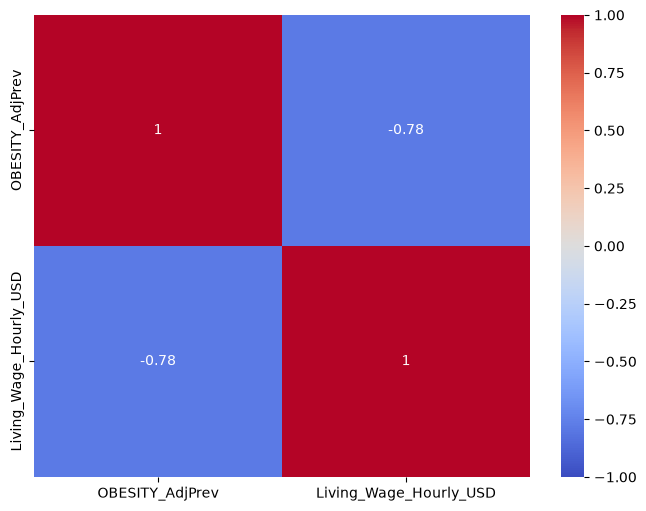

<Figure size 640x480 with 0 Axes>

In [44]:
corr_matrix = final_dataset[["OBESITY_AdjPrev", "Living_Wage_Hourly_USD"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()
plt.savefig('../results/figures/correlation_heatmap.svg', format='svg')


In [45]:
import pandas as pd

county_to_fips = {
    "Alameda": "06001",
    "Alpine": "06003",                      
    "Amador": "06005",
    "Butte": "06007",
    "Calaveras": "06009",
    "Colusa": "06011",
    "Contra Costa": "06013",
    "Del Norte": "06015",
    "El Dorado": "06017",
    "Fresno": "06019",
    "Glenn": "06021",
    "Humboldt": "06023",
    "Imperial": "06025",
    "Inyo": "06027",
    "Kern": "06029",
    "Kings": "06031",
    "Lake": "06033",
    "Lassen": "06035",
    "Los Angeles": "06037",
    "Madera": "06039",
    "Marin": "06041",
    "Mariposa": "06043",
    "Mendocino": "06045",
    "Merced": "06047",
    "Modoc": "06049",
    "Mono": "06051",
    "Monterey": "06053",
    "Napa": "06055",
    "Nevada": "06057",
    "Orange": "06059",
    "Placer": "06061",
    "Plumas": "06063",
    "Riverside": "06065",
    "Sacramento": "06067",
    "San Benito": "06069",
    "San Bernardino": "06071",
    "San Diego": "06073",
    "San Francisco": "06075",
    "San Joaquin": "06077",
    "San Luis Obispo": "06079",
    "San Mateo": "06081",
    "Santa Barbara": "06083",
    "Santa Clara": "06085",
    "Santa Cruz": "06087",
    "Shasta": "06089",
    "Sierra": "06091",
    "Siskiyou": "06093",
    "Solano": "06095",
    "Sonoma": "06097",
    "Stanislaus": "06099",
    "Sutter": "06101",
    "Tehama": "06103",
    "Trinity": "06105",
    "Tulare": "06107",
    "Tuolumne": "06109",
    "Ventura": "06111",
    "Yolo": "06113",
    "Yuba": "06115",
}

# Example: if your dataframe has a column named 'county'
final_dataset["fips"] = final_dataset["CountyName"].str.title().map(county_to_fips)

print(final_dataset[["CountyName", "fips"]].head())

   CountyName   fips
29    Alameda  06001
19     Alpine  06003
4      Amador  06005
48      Butte  06007
26  Calaveras  06009


In [46]:
final_dataset.head()

,CountyName,OBESITY_AdjPrev,Living_Wage_Hourly_USD,fips
29,Alameda,22.5,22.64,06001
19,Alpine,28.7,19.28,06003
4,Amador,29.5,20.36,06005
48,Butte,30.6,18.80,06007
26,Calaveras,29.8,18.79,06009


In [47]:
final_dataset['fips'] = final_dataset['fips'].astype(str).str.split('.').str[0].str.zfill(5)

fig = px.choropleth(
    final_dataset,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations='fips',
    color='OBESITY_AdjPrev',
    color_continuous_scale="Viridis",
    scope="usa",
    labels={'OBESITY_AdjPrev': 'Obesity Prevalence (%)'},
    hover_name='CountyName',
    custom_data=['CountyName']
)

fig.update_traces(
    hovertemplate='<b>%{customdata[0]}</b><br>Obesity Prevalence (%): %{z}<extra></extra>'
)

fig.update_geos(
    fitbounds="locations", 
    visible=False
)

fig.show()
fig.write_html("../data/processed/ca-obesity-prevalence-map.html", include_plotlyjs='cdn', config={'responsive': True, 'displayModeBar': True})

In [ ]:
final_dataset['fips'] = final_dataset['fips'].astype(str).str.split('.').str[0].str.zfill(5)

fig = px.choropleth(
    final_dataset,
    geojson="https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
    locations='fips',
    color='Living_Wage_Hourly_USD',
    color_continuous_scale="Viridis",
    scope="usa",
    labels={'Living_Wage_Hourly_USD': 'Living Wage (Hourly USD)'},
    hover_name='CountyName',
    custom_data=['CountyName']
)

fig.update_traces(
    hovertemplate='<b>%{customdata[0]}</b><br>Living Wage (Hourly USD): %{z}<extra></extra>'
)

fig.update_geos(
    fitbounds="locations", 
    visible=False
)

fig.show()
fig.write_html("../results/figures/ca-living-wage-map.html", include_plotlyjs='cdn', config={'responsive': True, 'displayModeBar': True})